# 07 - EDA con fuentes externas

**Objetivo.** Iniciar el análisis exploratorio enriquecido con fuentes externas. En esta versión se integra Censo 2022 por comuna para construir tasas simples de oferta publicada respecto de población y superficie.

In [1]:
from pathlib import Path
import json
import re
import unicodedata
from datetime import datetime

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print

pd.set_option('display.max_columns', 140)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 180)


def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'data' / 'raw').exists() and (path / 'README.md').exists():
            return path
    raise FileNotFoundError('No se encontro la raiz del repo. Ejecutar dentro del proyecto.')

REPO_ROOT = find_repo_root()
RAW_DIR = REPO_ROOT / 'data' / 'raw'
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed'
REPORTS_DIR = PROCESSED_DIR / 'reports'
EXTERNAL_DIR = REPO_ROOT / 'Fuentes_de_enriquecimiento'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print('REPO_ROOT:', REPO_ROOT)
print('RAW_DIR:', RAW_DIR)
print('PROCESSED_DIR:', PROCESSED_DIR)

REPO_ROOT: C:\Users\arira\OneDrive\Documents\GitHub\TP_analitica_descriptiva_grupo1_2q2026
RAW_DIR: C:\Users\arira\OneDrive\Documents\GitHub\TP_analitica_descriptiva_grupo1_2q2026\data\raw
PROCESSED_DIR: C:\Users\arira\OneDrive\Documents\GitHub\TP_analitica_descriptiva_grupo1_2q2026\data\processed


## Carga de base inmobiliaria y Censo 2022

In [ ]:
BASE_CONSOLIDADA_CANDIDATES = [
    PROCESSED_DIR / 'df_publicaciones_consolidadas_con_outliers_v1.csv',
    PROCESSED_DIR / 'df_publicaciones_consolidadas_post_ajustes_con_flags_nulos_v1.csv',
    PROCESSED_DIR / 'df_publicaciones_consolidadas_con_flags_nulos_v1.csv',
    PROCESSED_DIR / 'df_publicaciones_consolidadas_v1.csv',
]

DATASETS_PIPELINE = [
    'df_preprocesado_meli_alq',
    'df_preprocesado_meli_alq_temp',
    'df_preprocesado_meli_vtas',
    'df_preprocesado_airbnb_temp',
    'df_preprocesado_argenprop_vtas',
    'df_preprocesado_argenprop_alq',
    'df_preprocesado_zonaprop_vtas',
    'df_preprocesado_zonaprop_alq',
]

CANONICAL_COLS = [
    'id_publicacion', 'fuente_norm', 'fuente', 'tipo_operacion_norm', 'tipo_operacion', 'url', 'fecha_extraccion',
    'scraped_at_utc', '_archivo_origen', 'titulo', 'descripcion', 'tipo_propiedad', 'moneda_norm', 'moneda',
    'precio', 'precio_texto', 'precio_m2_ref', 'precio_noche_estimado', 'precio_mensual_estimado', 'barrio',
    'barrio_norm', 'comuna', 'provincia', 'pais', 'direccion', 'direccion_completa', 'calle', 'altura',
    'latitud', 'longitud', 'superficie_ref_m2', 'ambientes_ref', 'dormitorios_ref', 'banios_ref', 'cocheras',
    'expensas', 'expensas_moneda'
]


def construir_base_consolidada_desde_individuales(processed_dir):
    frames = []
    fuentes_usadas = []

    for name in DATASETS_PIPELINE:
        candidates = [
            processed_dir / f'{name}_con_outliers_v1.csv',
            processed_dir / f'{name}_post_ajustes_con_flags_nulos_v1.csv',
            processed_dir / f'{name}_con_flags_nulos_v1.csv',
            processed_dir / f'{name}_v1.csv',
        ]
        source = next((path for path in candidates if path.exists()), None)
        if source is None:
            continue

        df = pd.read_csv(source, low_memory=False)
        cols = [
            col for col in df.columns
            if col in CANONICAL_COLS or col.endswith('_is_null') or col.endswith('_flag')
        ]
        tmp = df[cols].copy()
        tmp['dataset_preprocesado'] = name
        tmp['_archivo_base_usado'] = source.name
        frames.append(tmp)
        fuentes_usadas.append({'dataset': name, 'archivo': source.name, 'filas': len(tmp)})

    if not frames:
        raise FileNotFoundError('No existe base consolidada ni archivos individuales procesados. Ejecutar notebooks 02-04.')

    return pd.concat(frames, ignore_index=True, sort=False), pd.DataFrame(fuentes_usadas)


base_path = next((path for path in BASE_CONSOLIDADA_CANDIDATES if path.exists()), None)

if base_path is not None:
    df_base = pd.read_csv(base_path, low_memory=False)
    print('Base:', base_path.relative_to(REPO_ROOT), df_base.shape)
else:
    df_base, fuentes_base = construir_base_consolidada_desde_individuales(PROCESSED_DIR)
    print('Base construida desde archivos individuales procesados:', df_base.shape)
    display(fuentes_base)

censo_path = PROCESSED_DIR / 'censo_2022_comunas_v1.csv'
if not censo_path.exists():
    raise FileNotFoundError('No existe censo_2022_comunas_v1.csv. Ejecutar notebook 06.')

censo_2022 = pd.read_csv(censo_path)
print('Censo:', censo_2022.shape)


## Agregación por comuna

In [3]:
df_base_comuna = df_base[df_base['comuna'].notna()].copy()
df_base_comuna['comuna'] = df_base_comuna['comuna'].astype(int)

oferta_comuna = (
    df_base_comuna
    .groupby(['comuna', 'tipo_operacion_norm'])
    .size()
    .reset_index(name='publicaciones')
)

total_comuna = df_base_comuna.groupby('comuna').size().reset_index(name='publicaciones_totales')
base_enriquecida_comuna = total_comuna.merge(censo_2022, on='comuna', how='left')
base_enriquecida_comuna['publicaciones_por_1000_hab'] = base_enriquecida_comuna['publicaciones_totales'] / base_enriquecida_comuna['poblacion_total'] * 1000
base_enriquecida_comuna['publicaciones_por_km2'] = base_enriquecida_comuna['publicaciones_totales'] / base_enriquecida_comuna['superficie_km2']

display(base_enriquecida_comuna.sort_values('publicaciones_por_1000_hab', ascending=False))
base_enriquecida_comuna.to_csv(PROCESSED_DIR / 'eda_comunas_censo_oferta_v1.csv', index=False)

,comuna,publicaciones_totales,codigo_comuna_indec,comuna_texto,superficie_km2,poblacion_total,densidad_hab_km2,publicaciones_por_1000_hab,publicaciones_por_km2
0,1,10946,2007,Comuna 1,17.9,223554,12489.1,48.963561,611.508380
13,14,8740,2098,Comuna 14,15.9,248635,15637.4,35.151930,549.685535
12,13,9196,2091,Comuna 13,15.0,264385,17625.7,34.782609,613.066667
1,2,5273,2014,Comuna 2,6.3,161645,25657.9,32.620867,836.984127
14,15,4826,2105,Comuna 15,14.3,196876,13767.6,24.512891,337.482517
11,12,5571,2084,Comuna 12,15.7,236887,15088.3,23.517542,354.840764
2,3,4271,2021,Comuna 3,6.4,196240,30662.5,21.764166,667.343750
4,5,4158,2035,Comuna 5,6.7,194271,28995.7,21.403092,620.597015
6,7,3655,2049,Comuna 7,12.4,215896,17411.0,16.929448,294.758065
10,11,3346,2077,Comuna 11,14.1,204601,14510.7,16.353781,237.304965


## Visualización inicial de oferta relativa

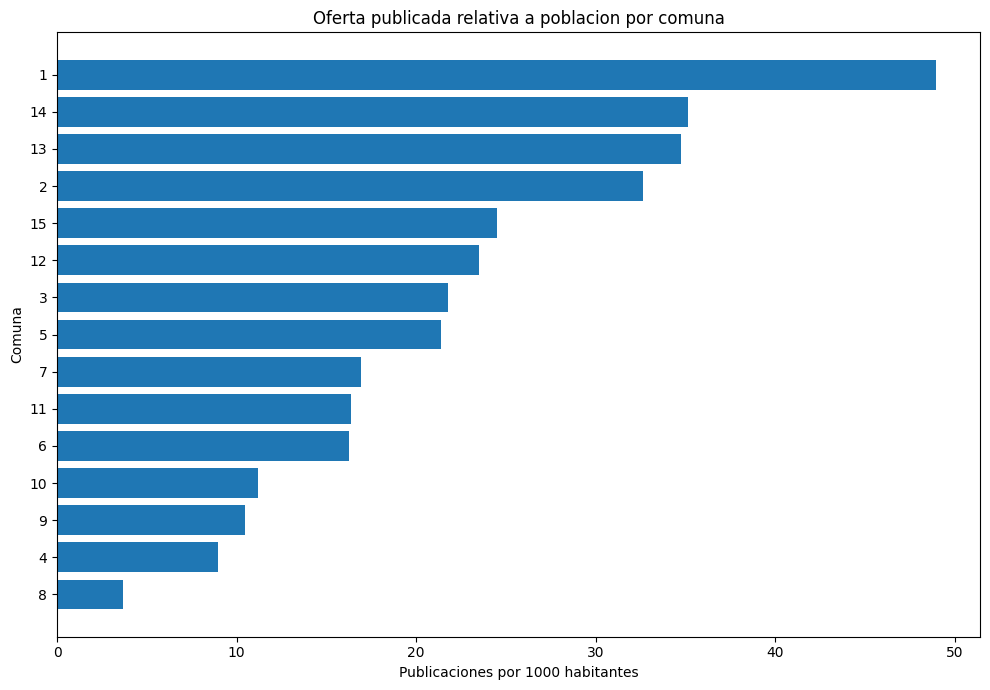

In [4]:
try:
    import matplotlib.pyplot as plt
    plot_df = base_enriquecida_comuna.sort_values('publicaciones_por_1000_hab')
    plt.figure(figsize=(10, 7))
    plt.barh(plot_df['comuna'].astype(str), plot_df['publicaciones_por_1000_hab'])
    plt.xlabel('Publicaciones por 1000 habitantes')
    plt.ylabel('Comuna')
    plt.title('Oferta publicada relativa a poblacion por comuna')
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(exc)

## Cruce por operación y comuna

In [5]:
oferta_operacion_comuna = oferta_comuna.merge(censo_2022[['comuna', 'poblacion_total', 'superficie_km2']], on='comuna', how='left')
oferta_operacion_comuna['publicaciones_por_1000_hab'] = oferta_operacion_comuna['publicaciones'] / oferta_operacion_comuna['poblacion_total'] * 1000
display(oferta_operacion_comuna.sort_values(['tipo_operacion_norm', 'publicaciones_por_1000_hab'], ascending=[True, False]).head(60))
oferta_operacion_comuna.to_csv(PROCESSED_DIR / 'eda_operacion_comuna_censo_v1.csv', index=False)

,comuna,tipo_operacion_norm,publicaciones,poblacion_total,superficie_km2,publicaciones_por_1000_hab
0,1,alquiler,1968,223554,17.9,8.803242
3,2,alquiler,1128,161645,6.3,6.978255
36,13,alquiler,1688,264385,15.0,6.384628
39,14,alquiler,1492,248635,15.9,6.000764
15,6,alquiler,802,203043,6.9,3.949902
33,12,alquiler,848,236887,15.7,3.579766
42,15,alquiler,551,196876,14.3,2.798716
12,5,alquiler,529,194271,6.7,2.723000
18,7,alquiler,572,215896,12.4,2.649424
6,3,alquiler,488,196240,6.4,2.486751


## Cierre EDA con fuentes externas

Estos cruces son descriptivos y agregados a comuna. Sirven para detectar concentración relativa de oferta, pero no explican diferencias entre barrios dentro de una misma comuna. Para etapas posteriores, las fuentes puntuales de transporte, salud, educación y cultura deberían integrarse mediante distancia o asignación geográfica.